In [ ]:
# ====================
# ЭТАП 1: Импорт библиотек и загрузка данных
# ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('cleaned_data_jobs_salaries_2023_2024.csv')

# Первичный осмотр данных
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())

Размер датасета: (4497, 40)

Первые 5 строк:
   spark  hourly location  work_year  remote_ratio company_txt  python_yn  \
0    NaN     NaN      NaN     2023.0         100.0         NaN        NaN   
1    NaN     NaN      NaN     2023.0         100.0         NaN        NaN   
2    NaN     NaN      NaN     2023.0         100.0         NaN        NaN   
3    NaN     NaN      NaN     2023.0         100.0         NaN        NaN   
4    NaN     NaN      NaN     2023.0         100.0         NaN        NaN   

  job title  r_yn  max_salary  ...  job description  avg_salary  \
0       NaN   NaN         NaN  ...              NaN         NaN   
1       NaN   NaN         NaN  ...              NaN         NaN   
2       NaN   NaN         NaN  ...              NaN         NaN   
3       NaN   NaN         NaN  ...              NaN         NaN   
4       NaN   NaN         NaN  ...              NaN         NaN   

                  job_title rating revenue employment_type competitors size  \
0  Princip

In [ ]:
# ====================
# ЭТАП 2: Предобработка данных
# ====================

# Оставляем только 2023 год для consistency (2024 данных мало)
df = df[df['work_year'] == 2023].copy()

# Выбираем целевые фичи для анализа
features_to_keep = [
    'work_year', 'remote_ratio', 'company_size', 'experience_level',
    'salary_currency', 'salary_in_usd', 'job_title', 'company_location',
    'employment_type'
]

df = df[features_to_keep].copy()

# Удаляем строки с пропусками в целевой переменной
df = df.dropna(subset=['salary_in_usd'])

# Заполняем пропуски в категориальных переменных
categorical_columns = ['company_size', 'experience_level', 'job_title', 'company_location', 'employment_type']
for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

print("Размер датасета после очистки:", df.shape)
print("\nРаспределение зарплат:")
print(df['salary_in_usd'].describe())

Размер датасета после очистки: (1785, 9)

Распределение зарплат:
count      1785.000000
mean     149045.541176
std       61307.711442
min        7000.000000
25%      107000.000000
50%      143860.000000
75%      184000.000000
max      423834.000000
Name: salary_in_usd, dtype: float64


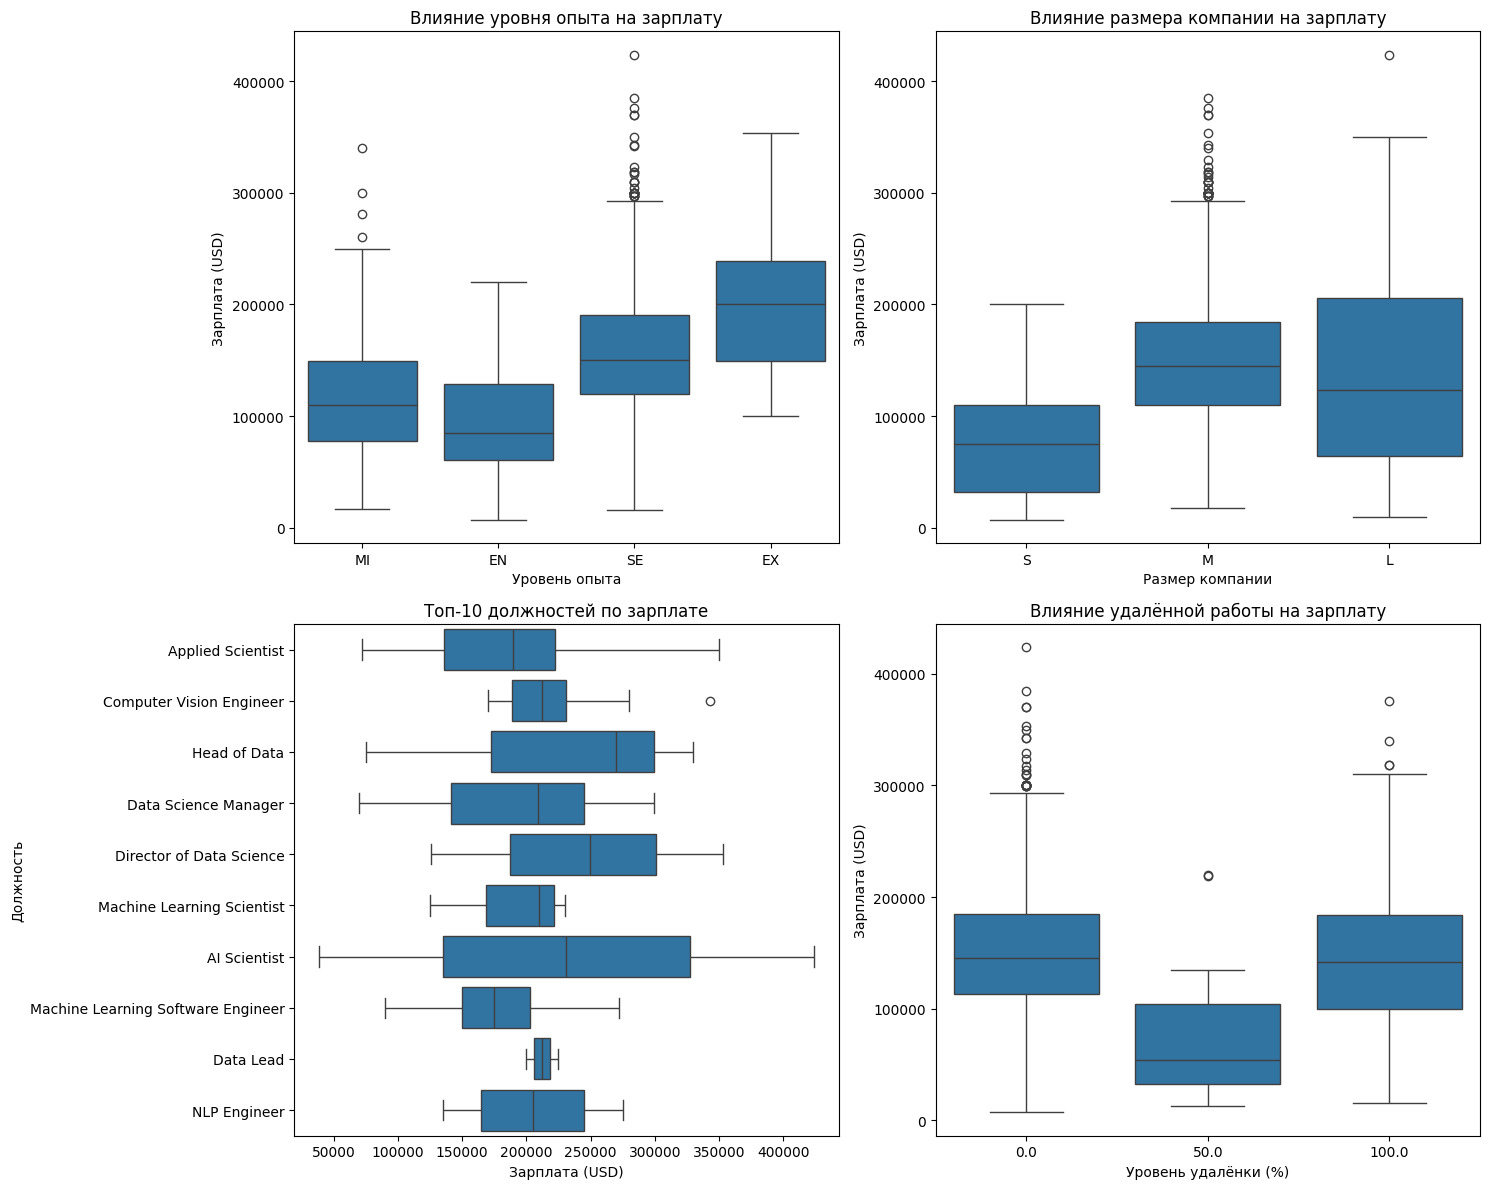

Корреляция удалённой работы с зарплатой: -0.05325982236418243


In [ ]:
# ====================
# ЭТАП 3: Анализ влияния факторов на зарплату
# ====================

# Визуализация влияния основных факторов
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Влияние уровня опыта
experience_order = ['MI', 'EN', 'SE', 'EX']  # Mid, Entry, Senior, Executive
df_exp = df[df['experience_level'].isin(experience_order)]
sns.boxplot(data=df_exp, x='experience_level', y='salary_in_usd', ax=axes[0,0], order=experience_order)
axes[0,0].set_title('Влияние уровня опыта на зарплату')
axes[0,0].set_xlabel('Уровень опыта')
axes[0,0].set_ylabel('Зарплата (USD)')

# Влияние размера компании
company_size_order = ['S', 'M', 'L']  # Small, Medium, Large
df_size = df[df['company_size'].isin(company_size_order)]
sns.boxplot(data=df_size, x='company_size', y='salary_in_usd', ax=axes[0,1], order=company_size_order)
axes[0,1].set_title('Влияние размера компании на зарплату')
axes[0,1].set_xlabel('Размер компании')
axes[0,1].set_ylabel('Зарплата (USD)')

# Топ-10 должностей по средней зарплате
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
top_jobs_df = df[df['job_title'].isin(top_jobs.index)]
sns.boxplot(data=top_jobs_df, x='salary_in_usd', y='job_title', ax=axes[1,0])
axes[1,0].set_title('Топ-10 должностей по зарплате')
axes[1,0].set_xlabel('Зарплата (USD)')
axes[1,0].set_ylabel('Должность')

# Влияние удалённой работы
sns.boxplot(data=df, x='remote_ratio', y='salary_in_usd', ax=axes[1,1])
axes[1,1].set_title('Влияние удалённой работы на зарплату')
axes[1,1].set_xlabel('Уровень удалёнки (%)')
axes[1,1].set_ylabel('Зарплата (USD)')

plt.tight_layout()
plt.show()

# Статистический анализ корреляций
print("Корреляция удалённой работы с зарплатой:", df['remote_ratio'].corr(df['salary_in_usd']))

In [ ]:
# ====================
# ЭТАП 4: Подготовка данных для ML
# ====================

# Создаём копию для моделирования
ml_df = df.copy()

# Кодируем категориальные переменные
label_encoders = {}
categorical_features = ['company_size', 'experience_level', 'job_title', 'company_location', 'employment_type']

for feature in categorical_features:
    le = LabelEncoder()
    ml_df[feature] = le.fit_transform(ml_df[feature].astype(str))
    label_encoders[feature] = le

# Определяем признаки и целевую переменную
X = ml_df.drop('salary_in_usd', axis=1)
y = ml_df['salary_in_usd']

# Разделяем на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем числовые признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размеры выборок:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

ValueError: could not convert string to float: 'USD'

In [ ]:
# ====================
# ЭТАП 5: Обучение и сравнение моделей
# ====================

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Обучение модели
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Вычисление метрик
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

    print(f"{name}:")
    print(f"  MAE: ${mae:,.0f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²: {r2:.3f}")
    print("-" * 40)

# Сравнение моделей
results_df = pd.DataFrame(results).T
print("\nСравнение моделей:")
print(results_df.sort_values('R2', ascending=False))

NameError: name 'X_train_scaled' is not defined

In [ ]:
# ====================
# ЭТАП 6: Анализ важности признаков
# ====================

# Используем лучшую модель (обычно Random Forest или Gradient Boosting)
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков:")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Важность признаков для прогноза зарплаты')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'USD'

In [ ]:
# ====================
# ЭТАП 7: Прогноз зарплат для разных позиций
# ====================

# Функция для прогноза зарплаты
def predict_salary(model, work_year=2023, remote_ratio=50, company_size='M',
                  experience_level='SE', job_title='Data Scientist',
                  company_location='US', employment_type='FT'):

    # Создаём DataFrame с входными данными
    input_data = pd.DataFrame({
        'work_year': [work_year],
        'remote_ratio': [remote_ratio],
        'company_size': [company_size],
        'experience_level': [experience_level],
        'job_title': [job_title],
        'company_location': [company_location],
        'employment_type': [employment_type]
    })

    # Кодируем категориальные переменные
    for feature in categorical_features:
        if feature in input_data.columns:
            # Используем сохранённые энкодеры
            le = label_encoders[feature]
            try:
                input_data[feature] = le.transform(input_data[feature])
            except ValueError:
                # Если значение новое, используем самое частое
                input_data[feature] = le.transform([le.classes_[0]])[0]

    # Прогноз
    if isinstance(model, (LinearRegression, Ridge, Lasso)):
        input_scaled = scaler.transform(input_data)
        prediction = model.predict(input_scaled)[0]
    else:
        prediction = model.predict(input_data)[0]

    return prediction

# Тестируем прогноз для разных позиций
test_positions = [
    {'job_title': 'Data Scientist', 'experience_level': 'SE', 'company_location': 'US'},
    {'job_title': 'Machine Learning Engineer', 'experience_level': 'SE', 'company_location': 'US'},
    {'job_title': 'Data Engineer', 'experience_level': 'SE', 'company_location': 'US'},
    {'job_title': 'Data Analyst', 'experience_level': 'SE', 'company_location': 'US'},
    {'job_title': 'Applied Scientist', 'experience_level': 'SE', 'company_location': 'US'},
]

print("ПРОГНОЗ ЗАРПЛАТ ДЛЯ РАЗНЫХ ПОЗИЦИЙ (Senior уровень, США):")
print("=" * 60)

predictions = []
for position in test_positions:
    salary_pred = predict_salary(best_model, **position)
    predictions.append({
        'position': position['job_title'],
        'predicted_salary': salary_pred
    })
    print(f"{position['job_title']:.<30} ${salary_pred:,.0f}")

# Сортируем по убыванию зарплаты
predictions_df = pd.DataFrame(predictions).sort_values('predicted_salary', ascending=False)
print("\n" + "=" * 60)
print("РЕЙТИНГ ПОЗИЦИЙ ПО ПРОГНОЗИРУЕМОЙ ЗАРПЛАТЕ:")
print("=" * 60)
for i, row in predictions_df.iterrows():
    print(f"{row['position']:.<30} ${row['predicted_salary']:,.0f}")

ПРОГНОЗ ЗАРПЛАТ ДЛЯ РАЗНЫХ ПОЗИЦИЙ (Senior уровень, США):


AttributeError: 'RandomForestRegressor' object has no attribute 'estimators_'

In [ ]:
# ====================
# ЭТАП 8: Анализ лучших комбинаций параметров
# ====================

# Анализ лучших комбинаций для максимизации зарплаты
best_combinations = []

# Тестируем разные комбинации
experience_levels = ['SE', 'EX']
company_sizes = ['L', 'M']
locations = ['US', 'CA', 'GB']  # США, Канада, Великобритания
top_jobs_list = ['Principal Data Scientist', 'Applied Scientist', 'Machine Learning Engineer',
                'Data Architect', 'Research Scientist']

for job in top_jobs_list:
    for exp in experience_levels:
        for size in company_sizes:
            for loc in locations:
                try:
                    salary = predict_salary(
                        best_model,
                        job_title=job,
                        experience_level=exp,
                        company_size=size,
                        company_location=loc,
                        remote_ratio=100  # Полная удалёнка
                    )
                    best_combinations.append({
                        'job_title': job,
                        'experience_level': exp,
                        'company_size': size,
                        'company_location': loc,
                        'predicted_salary': salary
                    })
                except:
                    continue

# Сортируем по зарплате и выводим топ-10
best_combinations_df = pd.DataFrame(best_combinations)
top_10_combinations = best_combinations_df.sort_values('predicted_salary', ascending=False).head(10)

print("ТОП-10 ВЫСОКООПЛАЧИВАЕМЫХ КОМБИНАЦИЙ:")
print("=" * 80)
for i, row in top_10_combinations.iterrows():
    print(f"{row['job_title']:.<25} {row['experience_level']} | {
row['company_size']} | "
          f"{row['company_location']:.<5} ${row['predicted_salary']:,.0f}")

# Визуализация топ позиций
plt.figure(figsize=(12, 6))
top_positions = best_combinations_df.groupby('job_title')['predicted_salary'].max().sort_values(ascending=False).head(8)
sns.barplot(x=top_positions.values, y=top_positions.index)
plt.title('Топ-8 самых высокооплачиваемых позиций в IT')
plt.xlabel('Прогнозируемая зарплата (USD)')
plt.tight_layout()
plt.show()

KeyError: 'predicted_salary'